# ⚡ Module 3 — Warp-Level Programming

> **Series:** GPU Programming with Python & CUDA  
> **Prerequisites:** [Module 2 — Memory Management](02_memory_management.ipynb)  
> **Tools:** CuPy, NumPy, Matplotlib

A **warp** is the true unit of GPU execution — 32 threads that march in lockstep through instructions. Everything you've written so far has relied on the hardware managing warps invisibly. This module pulls back the curtain: you'll see how control flow, data exchange, occupancy, and hardware-accelerated matrix units all operate at the warp level.

### 🗺️ What You'll Learn
| Topic | Key Takeaway |
|---|---|
| **Warp Divergence** | Branching within a warp serialises — avoid or restructure |
| **Shuffle Instructions** | Threads swap values register-to-register, no shared mem needed |
| **Occupancy** | More active warps hide latency — but registers and shared mem limit how many fit |
| **Tensor Cores** | Dedicated matrix engines deliver 10–100× FP32 throughput for GEMM |
| **CUDA Graphs** | Capture a whole sequence of kernel launches and replay with near-zero CPU overhead |

## ⚙️ Setup

In [10]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt

props    = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = props['name'].decode()
sm_count = props['multiProcessorCount']

print(f"CuPy  version : {cp.__version__}")
print(f"NumPy version : {np.__version__}")
print(f"GPU           : {gpu_name}")
print(f"SMs           : {sm_count}")
print(f"Max threads / SM    : {props['maxThreadsPerMultiProcessor']}")
print(f"Max threads / block : {props['maxThreadsPerBlock']}")
print(f"Registers / SM      : {props['regsPerMultiprocessor']:,}")
print(f"Shared mem / SM     : {props['sharedMemPerMultiprocessor'] // 1024} KB")

CuPy  version : 14.0.1
NumPy version : 2.4.2
GPU           : NVIDIA GeForce RTX 4070 SUPER
SMs           : 56
Max threads / SM    : 1536
Max threads / block : 1024
Registers / SM      : 65,536
Shared mem / SM     : 100 KB


---
## 1 · Warp Divergence

### What is a warp?
The GPU executes threads in groups of **32 called warps**. All 32 threads in a warp execute the **same instruction** at the same time (SIMT — Single Instruction, Multiple Threads).

### What is divergence?
When threads in a warp take **different branches**, the GPU must execute *both* paths sequentially, masking off threads that shouldn't participate each time:

```
Warp (32 threads) hits:   if (threadIdx.x % 2 == 0) { A } else { B }

  Pass 1 → execute A:  [T0 ■ T2 ■ T4 ■ …]   (odd threads idle)
  Pass 2 → execute B:  [■ T1 ■ T3 ■ T5 …]   (even threads idle)
  Total cost: 2×
```

### How to avoid it
1. **Sort by branch** — ensure all threads in a warp take the same path
2. **Branchless arithmetic** — replace `if/else` with arithmetic expressions
3. **Warp-uniform conditions** — branch on values that are the same for all 32 threads (e.g. `blockIdx.x`)

> ⚠️ Divergence across *blocks* is free — only divergence within a *warp* costs you.

  Divergent     : 0.119 ms  (baseline)
  Non-divergent : 0.059 ms  (2.02× faster)
  Branchless    : 0.115 ms  (1.04× faster)


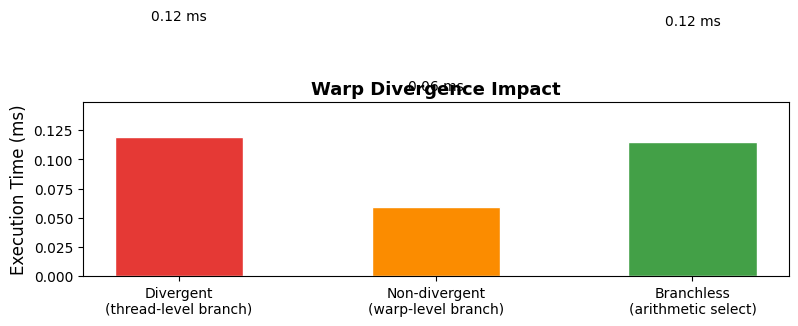

In [11]:
# ------------------------------------------------------------------
# Warp Divergence Benchmark
# ------------------------------------------------------------------

# ── Divergent: branch on thread index (splits every warp) ──────────
divergent_kernel = cp.RawKernel(r"""
extern "C" __global__
void divergent(const float* __restrict__ in, float* __restrict__ out, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= n) return;
    float v = in[i];
    // Branch decided per-thread → every warp diverges
    if (threadIdx.x % 2 == 0) {
        for (int k = 0; k < 32; k++) v = sqrtf(v + k);
    } else {
        for (int k = 0; k < 32; k++) v = v * 0.9999f + k;
    }
    out[i] = v;
}
""", "divergent")

# ── Non-divergent: same work, branch on warp index (uniform) ───────
nondivergent_kernel = cp.RawKernel(r"""
extern "C" __global__
void nondivergent(const float* __restrict__ in, float* __restrict__ out, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= n) return;
    float v = in[i];
    // Branch decided per-warp → all threads in a warp agree
    int warp_id = threadIdx.x / 32;
    if (warp_id % 2 == 0) {
        for (int k = 0; k < 32; k++) v = sqrtf(v + k);
    } else {
        for (int k = 0; k < 32; k++) v = v * 0.9999f + k;
    }
    out[i] = v;
}
""", "nondivergent")

# ── Branchless: select path with arithmetic, zero divergence ───────
branchless_kernel = cp.RawKernel(r"""
extern "C" __global__
void branchless(const float* __restrict__ in, float* __restrict__ out, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= n) return;
    float v = in[i];
    // Both paths computed; result selected with multiply — no branch
    float a = v, b = v;
    for (int k = 0; k < 32; k++) {
        a = sqrtf(a + k);
        b = b * 0.9999f + k;
    }
    float selector = (float)(threadIdx.x % 2 == 0);
    out[i] = selector * a + (1.0f - selector) * b;
}
""", "branchless")

N       = 1 << 22
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS
REPEATS = 200

src = cp.random.rand(N, dtype=cp.float32)
dst = cp.empty_like(src)

def bench(kernel):
    for _ in range(5):
        kernel((BLOCKS,), (THREADS,), (src, dst, N))
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        kernel((BLOCKS,), (THREADS,), (src, dst, N))
    cp.cuda.Stream.null.synchronize()
    return (time.perf_counter() - t0) / REPEATS * 1000  # ms

t_div  = bench(divergent_kernel)
t_ndiv = bench(nondivergent_kernel)
t_bl   = bench(branchless_kernel)

print(f"  Divergent     : {t_div:.3f} ms  (baseline)")
print(f"  Non-divergent : {t_ndiv:.3f} ms  ({t_div/t_ndiv:.2f}× faster)")
print(f"  Branchless    : {t_bl:.3f} ms  ({t_div/t_bl:.2f}× faster)")

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
labels  = ["Divergent\n(thread-level branch)", "Non-divergent\n(warp-level branch)", "Branchless\n(arithmetic select)"]
times   = [t_div, t_ndiv, t_bl]
colors  = ["#e53935", "#fb8c00", "#43a047"]
bars = ax.bar(labels, times, color=colors, edgecolor="white", width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{t:.2f} ms", ha="center", fontsize=10)
ax.set_ylabel("Execution Time (ms)", fontsize=12)
ax.set_title("Warp Divergence Impact", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()

### 🏋️ Challenge 3-1 — Divergence Detective

**Objective:** Identify and fix divergence in a real-world pattern: a histogram kernel.

**Background:** A naïve histogram has every thread atomically writing to a bin based on its data value. This is not divergent by itself — but a common optimisation attempt using `if/else` to special-case certain bins *is*.

**Your Task:**

1. Implement this **divergent histogram** kernel (branch on value range):
```c
extern "C" __global__
void histogram_divergent(const float* in, int* hist, int n, int bins) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= n) return;
    float v = in[i];
    int bin;
    if (v < 0.25f)      bin = (int)(v * bins * 4);       // branch A
    else if (v < 0.75f) bin = (int)((v - 0.25f) * bins * 2); // branch B
    else                bin = (int)((v - 0.75f) * bins * 4); // branch C
    atomicAdd(&hist[clamp(bin, 0, bins - 1)], 1);
}
```

2. Write a **branchless equivalent** using only arithmetic (no `if/else`).
3. Benchmark both. Is the speedup what you expected given 3-way divergence?
4. Verify both histograms match `np.histogram(data, bins=bins)`.

**Hint:** For branchless bin selection, think about how to express the piecewise linear function as a formula.

In [12]:
# 🏋️ Challenge 3-1 — Your solution here
# ---------------------------------------------------------------
N    = 1 << 24
BINS = 256

data = cp.random.rand(N, dtype=cp.float32)
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

# Step 1: Divergent histogram kernel
# hist_div_kernel = cp.RawKernel(r"""...""", "histogram_divergent")

# Step 2: Branchless histogram kernel
# hist_bl_kernel = cp.RawKernel(r"""...""", "histogram_branchless")

# Step 3: Benchmark
# ...

# Step 4: Verify against numpy
# ref_hist, _ = np.histogram(cp.asnumpy(data), bins=BINS, range=(0.0, 1.0))
# print("Match divergent  :", np.allclose(cp.asnumpy(hist_div), ref_hist))
# print("Match branchless :", np.allclose(cp.asnumpy(hist_bl),  ref_hist))

---
## 2 · Warp Shuffle Instructions

### The Problem with Shared Memory for Reductions
In Module 2's reduction challenge, threads shared intermediate results via `__shared__` memory and `__syncthreads()`. This works, but has overhead:
- Shared memory write + barrier + read = **3 steps** per reduction level

### Shuffle: Register-to-Register Communication
CUDA **shuffle intrinsics** let threads in a warp exchange values **directly between registers** — no memory, no barrier:

```
__shfl_down_sync(mask, val, delta)   // thread N reads from thread N+delta
__shfl_xor_sync (mask, val, mask)    // butterfly exchange
__shfl_up_sync  (mask, val, delta)   // thread N reads from thread N-delta
__shfl_sync     (mask, val, srcLane) // broadcast from lane srcLane
```

The `mask` (`0xffffffff`) tells the hardware which lanes participate.

### Warp Reduction with Shuffles
```
Initial:  [a0 a1 a2 a3 … a31]
delta=16: [a0+a16, a1+a17, …]     (first 16 lanes now hold partial sums)
delta=8:  [a0+a16+a8+a24, …]
delta=4:  [...]
delta=2:  [...]
delta=1:  [a0+a1+…+a31, ...]      lane 0 holds the warp sum
```
5 shuffles replace 5 rounds of shared-memory load/store — and they're **faster**.

  Reference (cp.sum) : 16775617.00
  Shuffle reduce     : 16775537.00   0.299 ms
  Shared-mem reduce  : 16775539.00   0.476 ms
  Shuffle speedup    : 1.59×

  Shuffle  bandwidth : 448.8 GB/s
  Shmem    bandwidth : 282.0 GB/s


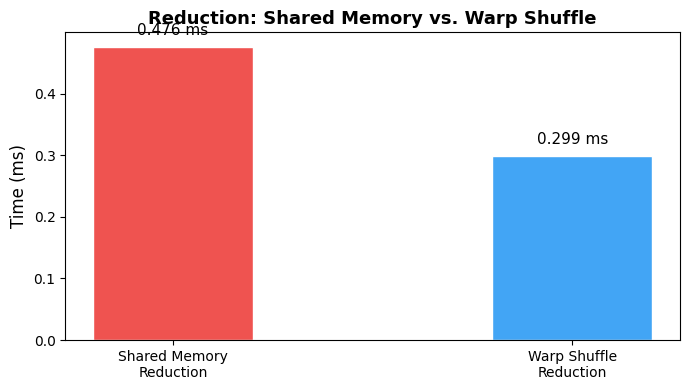

In [13]:
# ------------------------------------------------------------------
# Warp Shuffle Reduction vs. Shared Memory Reduction
# ------------------------------------------------------------------

shfl_reduce_kernel = cp.RawKernel(r"""
extern "C" __global__
void shfl_reduce(const float* __restrict__ in, float* __restrict__ out, int n) {
    int i   = blockDim.x * blockIdx.x + threadIdx.x;
    float v = (i < n) ? in[i] : 0.0f;

    // ── Warp-level reduction via shuffles (no shared mem needed) ──
    for (int delta = 16; delta >= 1; delta >>= 1)
        v += __shfl_down_sync(0xffffffff, v, delta);

    // ── One thread per warp writes the partial warp sum ───────────
    __shared__ float warp_sums[8];   // up to 8 warps per block (256/32)
    int warp_id = threadIdx.x / 32;
    int lane    = threadIdx.x % 32;
    if (lane == 0) warp_sums[warp_id] = v;
    __syncthreads();

    // ── First warp reduces the warp sums ──────────────────────────
    if (warp_id == 0) {
        int nwarps = blockDim.x / 32;
        v = (lane < nwarps) ? warp_sums[lane] : 0.0f;
        for (int delta = 4; delta >= 1; delta >>= 1)
            v += __shfl_down_sync(0xffffffff, v, delta);
        if (lane == 0) atomicAdd(out, v);
    }
}
""", "shfl_reduce")

shmem_reduce_kernel = cp.RawKernel(r"""
extern "C" __global__
void shmem_reduce(const float* __restrict__ in, float* __restrict__ out, int n) {
    __shared__ float sdata[256];
    int i   = blockDim.x * blockIdx.x + threadIdx.x;
    int tid = threadIdx.x;
    sdata[tid] = (i < n) ? in[i] : 0.0f;
    __syncthreads();

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] += sdata[tid + s];
        __syncthreads();
    }
    if (tid == 0) atomicAdd(out, sdata[0]);
}
""", "shmem_reduce")

N       = 1 << 25   # 32 M floats
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS
REPEATS = 200

arr = cp.random.rand(N, dtype=cp.float32)

def bench_reduce(kernel):
    out = cp.zeros(1, dtype=cp.float32)
    for _ in range(5):
        out[:] = 0
        kernel((BLOCKS,), (THREADS,), (arr, out, N))
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        out[:] = 0
        kernel((BLOCKS,), (THREADS,), (arr, out, N))
    cp.cuda.Stream.null.synchronize()
    elapsed = (time.perf_counter() - t0) / REPEATS
    return float(out[0]), elapsed * 1000

ref       = float(cp.sum(arr))
v_shfl,  t_shfl  = bench_reduce(shfl_reduce_kernel)
v_shmem, t_shmem = bench_reduce(shmem_reduce_kernel)

print(f"  Reference (cp.sum) : {ref:.2f}")
print(f"  Shuffle reduce     : {v_shfl:.2f}   {t_shfl:.3f} ms")
print(f"  Shared-mem reduce  : {v_shmem:.2f}   {t_shmem:.3f} ms")
print(f"  Shuffle speedup    : {t_shmem/t_shfl:.2f}×")

bw_shfl  = (N * 4) / (t_shfl  / 1000) / 1e9
bw_shmem = (N * 4) / (t_shmem / 1000) / 1e9
print(f"\n  Shuffle  bandwidth : {bw_shfl:.1f} GB/s")
print(f"  Shmem    bandwidth : {bw_shmem:.1f} GB/s")

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Shared Memory\nReduction", "Warp Shuffle\nReduction"],
       [t_shmem, t_shfl], color=["#ef5350", "#42a5f5"], edgecolor="white", width=0.4)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Reduction: Shared Memory vs. Warp Shuffle", fontsize=13, fontweight="bold")
for i, (label, t) in enumerate(zip(["Shmem", "Shuffle"], [t_shmem, t_shfl])):
    ax.text(i, t + 0.02, f"{t:.3f} ms", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

### 🏋️ Challenge 3-2 — Warp Scan (Prefix Sum)

**Objective:** Implement an **inclusive prefix sum** (scan) within a warp using only shuffle instructions.

**Background:** A prefix sum transforms `[a, b, c, d, …]` → `[a, a+b, a+b+c, a+b+c+d, …]`. It underlies stream compaction, sorting, and many other GPU algorithms.

**Warp scan algorithm using `__shfl_up_sync`:**
```
Step 1 (delta=1):  each thread adds value from lane-1
Step 2 (delta=2):  each thread adds value from lane-2
Step 3 (delta=4):  each thread adds value from lane-4
Step 4 (delta=8):  each thread adds value from lane-8
Step 5 (delta=16): each thread adds value from lane-16
→ lane k now holds sum of elements [0..k]
```

**Your Task:**
1. Implement `warp_scan` as a `RawKernel` using `__shfl_up_sync`.
2. Handle arrays of any size (not just multiples of 32) — process in 32-element chunks.
3. Verify against `np.cumsum`.
4. Benchmark vs `cp.cumsum`.

**Starter:**
```c
extern "C" __global__
void warp_scan(const float* in, float* out, int n) {
    int i    = blockDim.x * blockIdx.x + threadIdx.x;
    int lane = threadIdx.x % 32;
    float v  = (i < n) ? in[i] : 0.0f;

    // TODO: inclusive scan using __shfl_up_sync
    // for (int delta = 1; delta < 32; delta <<= 1) { ... }

    if (i < n) out[i] = v;
}
```

In [14]:
# 🏋️ Challenge 3-2 — Your solution here
# ---------------------------------------------------------------
N       = 1 << 20
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

arr = cp.random.rand(N, dtype=cp.float32)

# scan_kernel = cp.RawKernel(r"""...""", "warp_scan")
# out = cp.empty_like(arr)
# scan_kernel((BLOCKS,), (THREADS,), (arr, out, N))
# cp.cuda.Stream.null.synchronize()

# ref = np.cumsum(cp.asnumpy(arr))
# print("Max error:", np.max(np.abs(cp.asnumpy(out) - ref)))
# print("Match    :", np.allclose(cp.asnumpy(out), ref, rtol=1e-4, atol=1e-4))

---
## 3 · Occupancy

### What is occupancy?
**Occupancy** is the ratio of active warps on an SM to the maximum it can theoretically hold:

$$\text{Occupancy} = \frac{\text{Active warps per SM}}{\text{Max warps per SM}}$$

The RTX 4070 Super supports **up to 48 warps (1536 threads) per SM**. If your kernel only schedules 8 warps per SM, occupancy is 8/48 ≈ 17%.

### Why does occupancy matter?
When a warp **stalls** (waiting for memory, a barrier, etc.), the SM switches to another *ready* warp instantly — zero cost. Higher occupancy means more warps available to hide latency. But it's not always better:

```
Low occupancy  → few warps to hide latency → SM idles on memory stalls
High occupancy → many warps in flight      → latency hidden, good throughput
Too high occupancy (small blocks) → poor instruction-level parallelism
```

### What limits occupancy?
Three SM resources are partitioned among resident blocks:

| Resource | Effect if too large |
|---|---|
| **Threads** (block size × blocks) | Fewer blocks fit → lower occupancy |
| **Registers** per thread | Compiler spills to local memory or fewer blocks fit |
| **Shared memory** per block | Fewer blocks fit on SM |

### Choosing block size
- Powers of 2 between **128–512** are usually best
- 256 is the most common sweet spot
- Use `--ptxas-options=-v` (or Nsight Compute) to inspect register usage

  Block=  32  Occupancy≈100.0%  BW= 427.5 GB/s
  Block=  64  Occupancy≈100.0%  BW= 425.5 GB/s
  Block= 128  Occupancy≈100.0%  BW= 423.9 GB/s
  Block= 256  Occupancy≈100.0%  BW= 421.6 GB/s
  Block= 512  Occupancy≈100.0%  BW= 423.3 GB/s
  Block=1024  Occupancy≈ 66.7%  BW= 423.8 GB/s


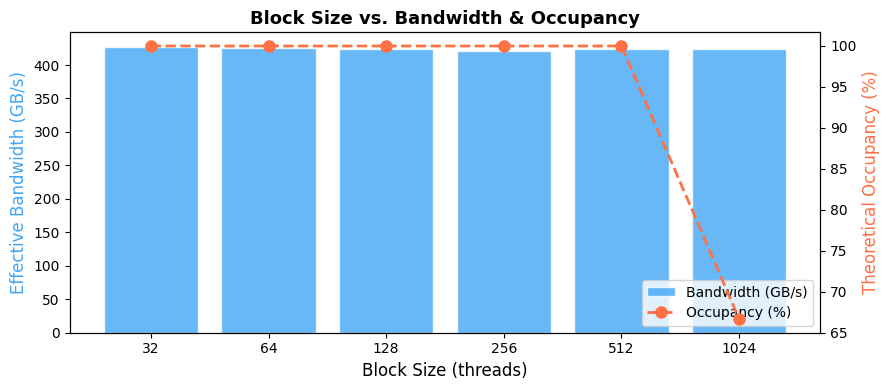

In [15]:
# ------------------------------------------------------------------
# Occupancy: Block Size vs. Throughput
# ------------------------------------------------------------------

# A memory-bound kernel (benefits from high occupancy to hide latency)
copy_kernel = cp.RawKernel(r"""
extern "C" __global__
void copy_kernel(const float* __restrict__ src,
                       float* __restrict__ dst, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) dst[i] = src[i] * 1.0001f;
}
""", "copy_kernel")

N       = 1 << 25
REPEATS = 300
src     = cp.random.rand(N, dtype=cp.float32)
dst     = cp.empty_like(src)

max_warps_per_sm = props['maxThreadsPerMultiProcessor'] // 32

block_sizes = [32, 64, 128, 256, 512, 1024]
results     = []

for bs in block_sizes:
    blocks = (N + bs - 1) // bs
    warps_per_block  = bs // 32
    # How many blocks fit per SM (limited by max threads per SM)
    blocks_per_sm    = props['maxThreadsPerMultiProcessor'] // bs
    active_warps     = blocks_per_sm * warps_per_block
    occupancy        = min(active_warps, max_warps_per_sm) / max_warps_per_sm * 100

    # Benchmark
    for _ in range(5):
        copy_kernel((blocks,), (bs,), (src, dst, N))
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        copy_kernel((blocks,), (bs,), (src, dst, N))
    cp.cuda.Stream.null.synchronize()
    elapsed = (time.perf_counter() - t0) / REPEATS
    bw = N * 4 * 2 / elapsed / 1e9

    results.append((bs, occupancy, bw))
    print(f"  Block={bs:>4}  Occupancy≈{occupancy:5.1f}%  BW={bw:6.1f} GB/s")

# ── Plot ────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

bs_vals  = [r[0] for r in results]
occ_vals = [r[1] for r in results]
bw_vals  = [r[2] for r in results]

ax1.bar([str(b) for b in bs_vals], bw_vals, color="#42a5f5", alpha=0.8,
        edgecolor="white", label="Bandwidth (GB/s)")
ax2.plot([str(b) for b in bs_vals], occ_vals, "o--", color="#ff7043",
         linewidth=2, markersize=8, label="Occupancy (%)")

ax1.set_xlabel("Block Size (threads)", fontsize=12)
ax1.set_ylabel("Effective Bandwidth (GB/s)", fontsize=12, color="#42a5f5")
ax2.set_ylabel("Theoretical Occupancy (%)", fontsize=12, color="#ff7043")
ax1.set_title("Block Size vs. Bandwidth & Occupancy", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
plt.tight_layout()
plt.show()

### 🏋️ Challenge 3-3 — Shared Memory Occupancy Cliff

**Objective:** Observe how increasing shared memory per block drops occupancy and hurts throughput.

**Background:** The RTX 4070 Super has **100 KB shared memory per SM**. If your block uses 50 KB, only 2 blocks fit per SM. With 256 threads/block → 16 warps/SM, vs the max of 48 — occupancy drops to 33%.

**Your Task:**

1. Write a kernel that uses a configurable amount of shared memory per block (pad it to prevent the compiler from optimising it away):
```c
extern "C" __global__
void shmem_hog(float* out, int n, int shmem_floats) {
    extern __shared__ float sdata[];
    // Touch shared mem to prevent dead-code elimination
    for (int i = threadIdx.x; i < shmem_floats; i += blockDim.x)
        sdata[i] = threadIdx.x;
    __syncthreads();
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    if (idx < n) out[idx] = sdata[threadIdx.x % shmem_floats];
}
```

2. Sweep `shmem_kb` from `0` to `48` KB in steps of 4 KB.
3. For each: compute theoretical occupancy and benchmark throughput.
4. Plot occupancy vs. throughput — find the cliff.

**Hint:** Pass dynamic shared memory size as the 4th argument to the kernel launch:
```python
kernel((blocks,), (threads,), args, shared_mem=shmem_bytes)
```

In [16]:
# 🏋️ Challenge 3-3 — Your solution here
# ---------------------------------------------------------------
# shmem_hog_kernel = cp.RawKernel(r"""...""", "shmem_hog")

# N        = 1 << 22
# THREADS  = 256
# BLOCKS   = (N + THREADS - 1) // THREADS
# out      = cp.empty(N, dtype=cp.float32)
# shmem_sm = props['sharedMemPerMultiprocessor']

# for kb in range(0, 52, 4):
#     shmem_bytes  = kb * 1024
#     shmem_floats = shmem_bytes // 4
#     blocks_per_sm = shmem_sm // max(shmem_bytes, 1)
#     active_warps  = min(blocks_per_sm * (THREADS // 32), max_warps_per_sm)
#     occupancy     = active_warps / max_warps_per_sm * 100
#     # benchmark...
#     print(f"  {kb:>2} KB shmem/block  Occupancy≈{occupancy:.0f}%  BW=... GB/s")

---
## 4 · Tensor Cores

### What are Tensor Cores?
Standard CUDA cores execute one **FMA** (fused multiply-add) per thread per clock. **Tensor Cores** are dedicated matrix-multiply units introduced in Volta that execute a full **D = A×B + C** for a small tile in a *single warp instruction*:

| Generation | Tile Size | Supported Types | Peak FP16 TFLOP/s (RTX 4070 Super) |
|---|---|---|---|
| Volta (V100) | 4×4 (FP16) | FP16, INT8 | — |
| Ampere (A100) | 8×16 | FP16, BF16, TF32, INT8 | — |
| Ada (RTX 40xx) | 8×16 | FP16, BF16, TF32, INT8, FP8 | **~145** |

The RTX 4070 Super has **60 TFLOP/s FP32** but **~145 TFLOP/s FP16** — Tensor Cores give a **~2.4× boost** even for FP16.

### How to use them in CuPy
You don't need WMMA intrinsics directly. CuPy routes `cp.matmul` through **cuBLAS**, which automatically dispatches to Tensor Cores when:
1. Input dtype is `float16` or `bfloat16`
2. Matrix dimensions are multiples of 8 (16 for best performance)

```python
A = cp.random.rand(M, K, dtype=cp.float16)
B = cp.random.rand(K, N, dtype=cp.float16)
C = cp.matmul(A, B)   # → Tensor Cores engaged automatically
```

  Size    FP32 TFLOP/s    FP16 TFLOP/s   Speedup
──────────────────────────────────────────────────
  512²    13.28 TFLOP/s    25.72 TFLOP/s   1.94×
  1024²    17.84 TFLOP/s    54.76 TFLOP/s   3.07×
  2048²    24.23 TFLOP/s    64.32 TFLOP/s   2.65×
  4096²    24.97 TFLOP/s    73.53 TFLOP/s   2.94×


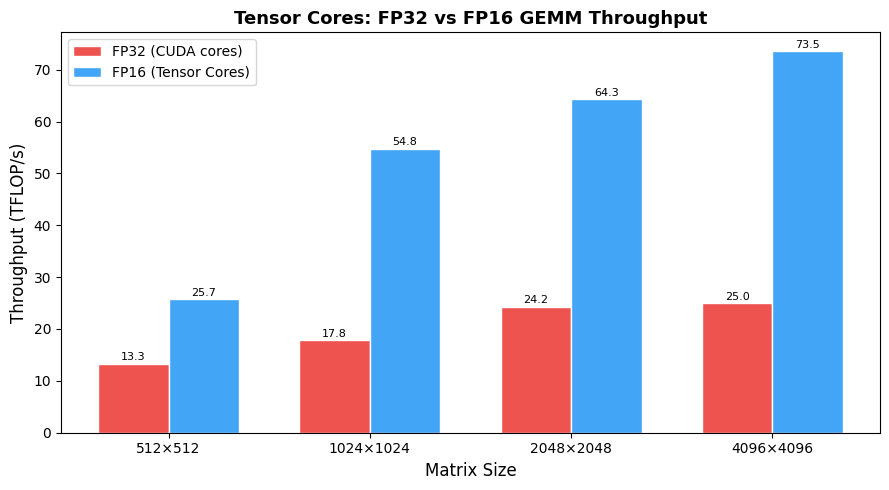

In [17]:
# ------------------------------------------------------------------
# Tensor Core Benchmark: FP32 vs FP16 vs BF16 GEMM
# ------------------------------------------------------------------

def bench_gemm(dtype, M, K, N, repeats=100):
    # Dimensions aligned to 16 for Tensor Core efficiency
    A = cp.random.rand(M, K).astype(dtype)
    B = cp.random.rand(K, N).astype(dtype)
    # warm-up
    for _ in range(5):
        C = cp.matmul(A, B)
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        C = cp.matmul(A, B)
    cp.cuda.Stream.null.synchronize()
    elapsed = (time.perf_counter() - t0) / repeats
    flops   = 2 * M * K * N                    # multiply-adds
    tflops  = flops / elapsed / 1e12
    return tflops, elapsed * 1000

sizes = [512, 1024, 2048, 4096]
dtypes = [
    (cp.float32,  "FP32\n(CUDA cores)"),
    (cp.float16,  "FP16\n(Tensor Cores)"),
]

print(f"{'Size':>6}  {'FP32 TFLOP/s':>14}  {'FP16 TFLOP/s':>14}  {'Speedup':>8}")
print("─" * 50)

all_results = {label: [] for _, label in dtypes}

for M in sizes:
    row = f"  {M}²"
    for dtype, label in dtypes:
        tf, ms = bench_gemm(dtype, M, M, M)
        all_results[label].append(tf)
        row += f"   {tf:>6.2f} TFLOP/s"
    speedup = all_results["FP16\n(Tensor Cores)"][-1] / all_results["FP32\n(CUDA cores)"][-1]
    print(row + f"   {speedup:.2f}×")

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(sizes))
width = 0.35
colors_map = {"FP32\n(CUDA cores)": "#ef5350", "FP16\n(Tensor Cores)": "#42a5f5"}

for i, (_, label) in enumerate(dtypes):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, all_results[label], width,
                  label=label.replace("\n", " "),
                  color=colors_map[label], edgecolor="white")
    for bar, v in zip(bars, all_results[label]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{s}×{s}" for s in sizes])
ax.set_xlabel("Matrix Size", fontsize=12)
ax.set_ylabel("Throughput (TFLOP/s)", fontsize=12)
ax.set_title("Tensor Cores: FP32 vs FP16 GEMM Throughput", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 🏋️ Challenge 3-4 — Mixed Precision Matmul Pipeline

**Objective:** Implement a mixed-precision GEMM pipeline that stores weights in **FP16** but accumulates in **FP32** — the standard pattern in deep learning training.

**Background:** Pure FP16 arithmetic can overflow or lose precision for large accumulations. The solution is:
- **Inputs/weights:** FP16 (half bandwidth, Tensor Core eligible)
- **Accumulator:** FP32 (full range, numerical stability)
- **Output:** cast back to FP16 if needed for the next layer

**Your Task:**
1. Generate matrices `A (M×K)` in FP16 and `B (K×N)` in FP16.
2. Compute `C_fp16 = (A @ B)` fully in FP16.
3. Compute `C_mixed = (A.astype(fp32) @ B.astype(fp32))` — this is the reference.
4. Compute `C_cublas = cp.matmul(A, B, dtype=cp.float32)` — cuBLAS mixed precision path.
5. Compare numerical accuracy: `max(|C_fp16 - C_mixed|)` vs `max(|C_cublas - C_mixed|)`.
6. Benchmark all three and report TFLOP/s.

**Expected Result:** `C_cublas` should be significantly more accurate than `C_fp16` with only a modest speed penalty compared to pure FP16.

**Hint:** `cp.matmul` accepts a `dtype` kwarg that controls the accumulator precision on newer CuPy/cuBLAS versions.

In [18]:
# 🏋️ Challenge 3-4 — Your solution here
# ---------------------------------------------------------------
M, K, N = 2048, 2048, 2048
REPEATS  = 50

A_fp16 = cp.random.rand(M, K).astype(cp.float16)
B_fp16 = cp.random.rand(K, N).astype(cp.float16)

# Step 2: Pure FP16 matmul
# C_fp16  = cp.matmul(A_fp16, B_fp16)

# Step 3: FP32 reference
# C_mixed = cp.matmul(A_fp16.astype(cp.float32), B_fp16.astype(cp.float32))

# Step 4: cuBLAS mixed precision (FP16 inputs, FP32 accumulator)
# C_cublas = cp.matmul(A_fp16, B_fp16, dtype=cp.float32)

# Step 5: Accuracy comparison
# err_fp16   = float(cp.max(cp.abs(C_fp16.astype(cp.float32)   - C_mixed)))
# err_cublas = float(cp.max(cp.abs(C_cublas                    - C_mixed)))
# print(f"Max error  FP16 pure    : {err_fp16:.4f}")
# print(f"Max error  cuBLAS mixed : {err_cublas:.4f}")

# Step 6: Benchmark
# ...

---
## 5 · CUDA Graphs

### The Problem: Kernel Launch Overhead
Every time you call a CUDA kernel from Python/CPU, there is **CPU-side overhead**:
- Python → CuPy → cuBLAS/NVRTC → CUDA driver → GPU
- Typically **5–20 µs per launch**

For a pipeline of 100 small kernels, this adds up to **1–2 ms of pure CPU overhead** — even if each kernel only takes 10 µs on the GPU.

### CUDA Graphs: Record Once, Replay Many Times
CUDA Graphs let you **capture** a sequence of operations into a graph, then **launch the entire graph** with a single driver call:

```
Record phase:  stream.begin_capture()
               kernel_A(...)
               kernel_B(...)
               kernel_C(...)
               graph = stream.end_capture()

Replay phase:  graph_exec = graph.instantiate()
               graph_exec.launch(stream)   ← one driver call for all three
```

The graph is stored on the GPU. Replaying it costs **~1–5 µs** regardless of how many nodes it contains.

### When to use CUDA Graphs
| Use Case | Benefit |
|---|---|
| Inference pipelines (fixed topology) | Eliminate per-layer launch latency |
| Iterative algorithms (same ops each step) | Near-zero CPU overhead per iteration |
| Kernels shorter than ~50 µs | Launch overhead is significant fraction |
| Dynamic shapes or allocations | ❌ Graphs don't support runtime shape changes |